# GlowWise AI - Model Comparison & Optimization 📊

This notebook implements the model comparison and hyperparameter tuning pipeline for Predicting Skincare Review Satisfaction (`high_satisfaction`). We compare seven distinct machine learning models and select the best candidate for deployment using a structured ranking strategy.

### Why Model Comparison Matters
In machine learning, there is no single algorithm that is optimal for all problems (No Free Lunch theorem). To find the best solution, we must:
1. **Compare diverse architectures**: Linear models (Logistic Regression, Linear SVC, SGD Classifier), probabilistic models (Complement Naive Bayes), and metadata-enhanced models combining text features and user profile categorical traits.
2. **Tune hyperparameters**: Conduct systematic optimization (Grid Search) to tune the TF-IDF representation scale and logistic regularization strength.
3. **Select based on robust metrics**: Due to the severe class imbalance (~82% vs ~18%), we optimize for **Macro F1-Score** (primary metric) and **Minority Class (Class 0) Recall** (secondary metric) to ensure critical feedback is successfully flagged.


In [1]:
import sys
import json
import joblib
import time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Adjust styling for clean premium visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#332633'
plt.rcParams['axes.labelcolor'] = '#332633'
plt.rcParams['xtick.color'] = '#332633'
plt.rcParams['ytick.color'] = '#332633'

# Premium color variables matching the GlowWise wellness theme
COLOR_PLUM = '#3B243B'
COLOR_GOLD = '#C39B6F'
COLOR_ROSE = '#E8D3C4'
COLOR_LIGHT_PLUM = '#5C3D5C'
COLOR_CREAM = '#FCFAF7'
COLOR_MUTED = '#6E5C6E'

# Resolve project root path dynamically
current_path = Path.cwd().resolve()
root_dir = None
for parent in [current_path] + list(current_path.parents):
    if (parent / "README.md").exists():
        root_dir = parent
        break
if root_dir is None:
    root_dir = current_path.parent if 'notebooks' in current_path.name else current_path

sys.path.append(str(root_dir / "ml" / "src"))
from evaluate_model import calculate_metrics, plot_confusion_matrix

figures_dir = root_dir / "ml" / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


## 1. Load Processed Dataset

We load the preprocessed sample dataset and apply empty string imputation to text fields (`review_title`, `ingredients`, `combined_text`, `review_text`) to guarantee no missing values are loaded.


In [2]:
data_path = root_dir / "data" / "processed" / "glowwise_reviews_sample_100k.csv"
print(f"Loading dataset: {data_path.name}")
df = pd.read_csv(data_path)

# Safe imputation for all columns
for col in ["review_title", "review_text", "combined_text", "ingredients"]:
    if col in df.columns:
        df[col] = df[col].fillna("")
        
for col in ["brand_name", "skin_type", "primary_category", "secondary_category"]:
    if col in df.columns:
        df[col] = df[col].fillna("unknown").astype(str)
        
if "price_usd" in df.columns:
    df["price_usd"] = pd.to_numeric(df["price_usd"], errors="coerce")
    df["price_usd"] = df["price_usd"].fillna(df["price_usd"].median())

# Drop missing target or empty text
df = df.dropna(subset=["high_satisfaction"])
df = df[df["combined_text"].str.strip() != ""]
print(f"Data shape: {df.shape}")


Loading dataset: glowwise_reviews_sample_100k.csv


Data shape: (100000, 20)


C:\Users\mahta\AppData\Local\Temp\ipykernel_3316\1319426666.py:3: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


## 2. Evaluation Strategy for Imbalanced Data

The target variable exhibits a severe class imbalance. Predicting the majority class yields **82.08% accuracy**, but fails to identify any dissatisfied review (recall of 0.00% on class 0).


In [3]:
target_counts = df["high_satisfaction"].value_counts()
target_pcts = df["high_satisfaction"].value_counts(normalize=True) * 100
for idx in target_counts.index:
    label = "high_satisfaction (1)" if idx == 1 else "low_or_medium_satisfaction (0)"
    print(f"{label:30} : {target_counts[idx]:,} ({target_pcts[idx]:.2f}%)")


high_satisfaction (1)          : 82,084 (82.08%)
low_or_medium_satisfaction (0) : 17,916 (17.92%)


## 3. Stratified Split

We perform an 80/20 train/test split, stratifying on the target to preserve class ratios.


In [4]:
X = df
y = df["high_satisfaction"].astype(int)

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train_text = X_train_df["combined_text"].astype(str)
X_test_text = X_test_df["combined_text"].astype(str)


## 4. Models Comparison & Hyperparameter Tuning

We train all 7 models. For the **Tuned Logistic Regression**, we perform a grid search over:
- `tfidf__max_features`: `[10000, 20000]`
- `tfidf__ngram_range`: `[(1,1), (1,2)]`
- `lr__C`: `[0.5, 1.0, 2.0]`


In [5]:
results = {}
fitted_models = {}

# Helper to train and log
def train_model(name, pipeline, is_text_only=True, is_grid=False):
    t0 = time.time()
    if is_grid:
        pipeline.fit(X_train_text, y_train)
        pred = pipeline.predict(X_test_text)
    elif is_text_only:
        pipeline.fit(X_train_text, y_train)
        pred = pipeline.predict(X_test_text)
    else:
        pipeline.fit(X_train_df, y_train)
        pred = pipeline.predict(X_test_df)
    elapsed = time.time() - t0
    
    metrics = calculate_metrics(y_test, pred)
    metrics["training_time_seconds"] = elapsed
    results[name] = metrics
    fitted_models[name] = pipeline.best_estimator_ if is_grid else pipeline
    print(f"Model {name} trained in {elapsed:.2f}s")

# 1. Dummy
train_model("dummy_classifier", DummyClassifier(strategy="most_frequent"))

# 2. LR Baseline
train_model("logistic_regression_baseline", Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("lr", LogisticRegression(class_weight="balanced", random_state=42, max_iter=2000))
]))

# 3. LR Tuned (GridSearch)
grid = GridSearchCV(
    Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("lr", LogisticRegression(class_weight="balanced", random_state=42, max_iter=2000))
    ]),
    {"tfidf__max_features": [10000, 20000], "tfidf__ngram_range": [(1, 1), (1, 2)], "lr__C": [0.5, 1.0, 2.0]},
    cv=3, scoring="f1_macro", n_jobs=-1
)
train_model("logistic_regression_tuned", grid, is_grid=True)

# 4. Linear SVC
train_model("linear_svc", Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("svc", LinearSVC(class_weight="balanced", random_state=42, max_iter=2000))
]))

# 5. Complement NB
train_model("complement_nb", Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("cnb", ComplementNB())
]))

# 6. SGD Classifier
train_model("sgd_classifier", Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("sgd", SGDClassifier(loss="hinge", class_weight="balanced", random_state=42))
]))

# 7. Metadata-Enhanced LR
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=10000, ngram_range=(1, 2)), "combined_text"),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["brand_name", "skin_type", "primary_category", "secondary_category"]),
        ("num", StandardScaler(), ["price_usd", "text_length", "word_count"])
    ]
)
train_model("metadata_enhanced_lr", Pipeline([
    ("preprocessor", preprocessor),
    ("lr", LogisticRegression(class_weight="balanced", random_state=42, max_iter=2000))
]), is_text_only=False)


Model dummy_classifier trained in 0.00s


Model logistic_regression_baseline trained in 7.86s


Model logistic_regression_tuned trained in 72.91s


Model linear_svc trained in 11.75s


Model complement_nb trained in 11.34s


Model sgd_classifier trained in 11.88s


Model metadata_enhanced_lr trained in 15.38s


## 5. Results Comparison

We summarize and format all evaluations in a Pandas DataFrame for comparison.


In [6]:
summary_data = []
for name, m in results.items():
    summary_data.append({
        "Model": name,
        "Accuracy": m["accuracy"],
        "Macro F1": m["macro"]["f1_score"],
        "Weighted F1": m["weighted"]["f1_score"],
        "Class 0 Recall": m["per_class"]["low_or_medium_satisfaction"]["recall"],
        "Class 0 Precision": m["per_class"]["low_or_medium_satisfaction"]["precision"],
        "Train Time (s)": m["training_time_seconds"]
    })

summary_df = pd.DataFrame(summary_data).sort_values("Macro F1", ascending=False)
summary_df


,Model,Accuracy,Macro F1,Weighted F1,Class 0 Recall,Class 0 Precision,Train Time (s)
2,logistic_regression_tuned,0.92955,0.889140,0.932090,0.909294,0.750345,72.910910
6,metadata_enhanced_lr,0.92240,0.879650,0.925678,0.910968,0.725817,15.375790
3,linear_svc,0.92370,0.879372,0.926296,0.886129,0.739576,11.747527
1,logistic_regression_baseline,0.91850,0.874663,0.922228,0.912922,0.712791,7.863416
5,sgd_classifier,0.91350,0.868776,0.917936,0.920179,0.695423,11.881620
4,complement_nb,0.89010,0.839785,0.897399,0.920179,0.632943,11.342796
0,dummy_classifier,0.82085,0.450806,0.740088,0.000000,0.000000,0.001572


## 6. Performance Visualizations

We display the generated comparative bar plots to inspect classification performance and minority class recall.


=== Performance Metrics Comparison ===


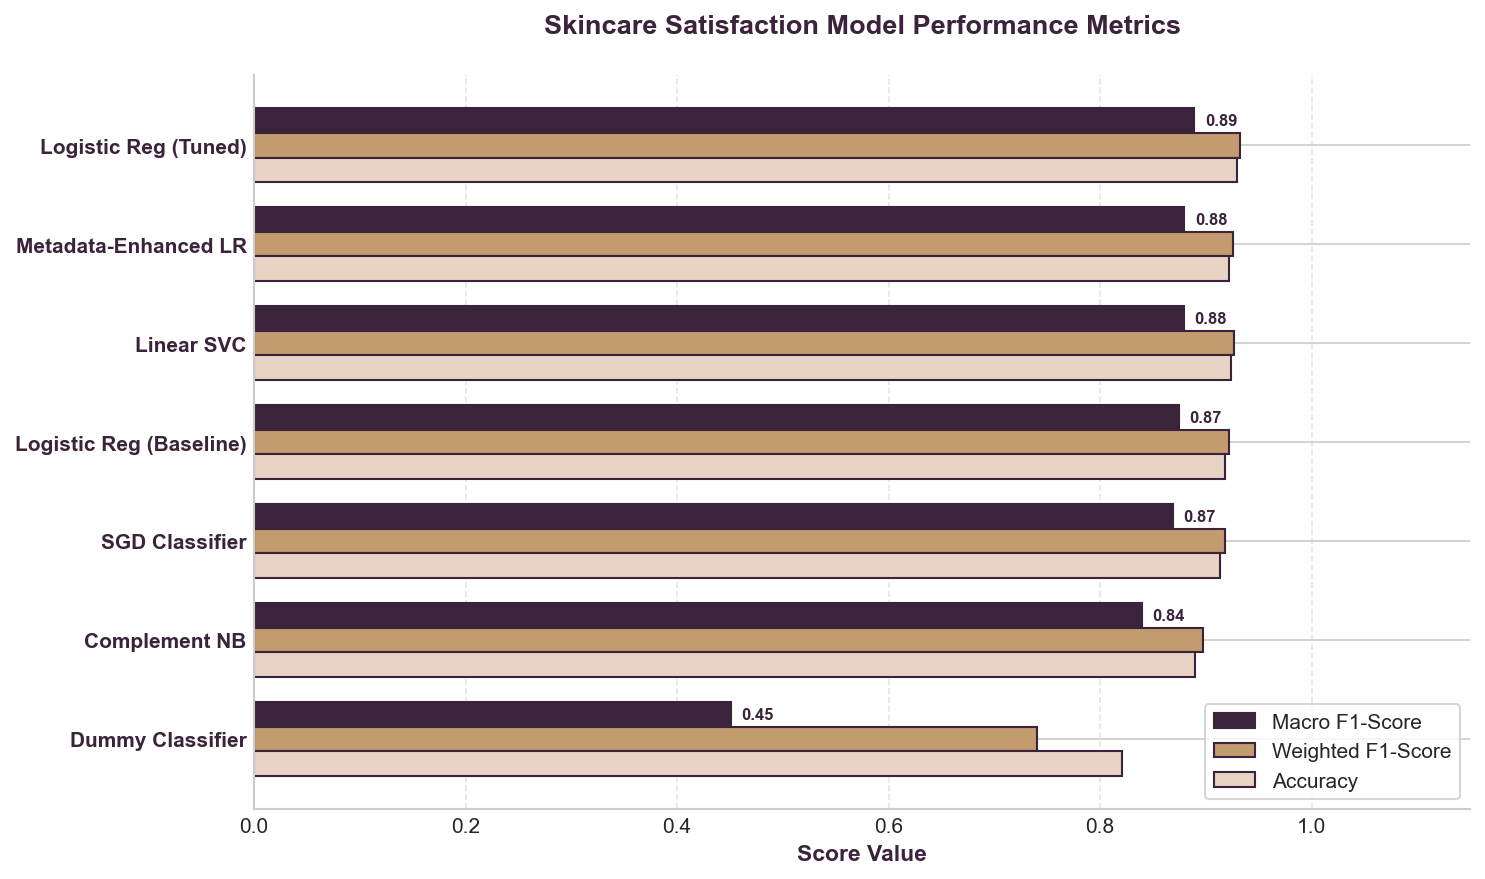


=== Class 0 Recall & Precision Comparison ===


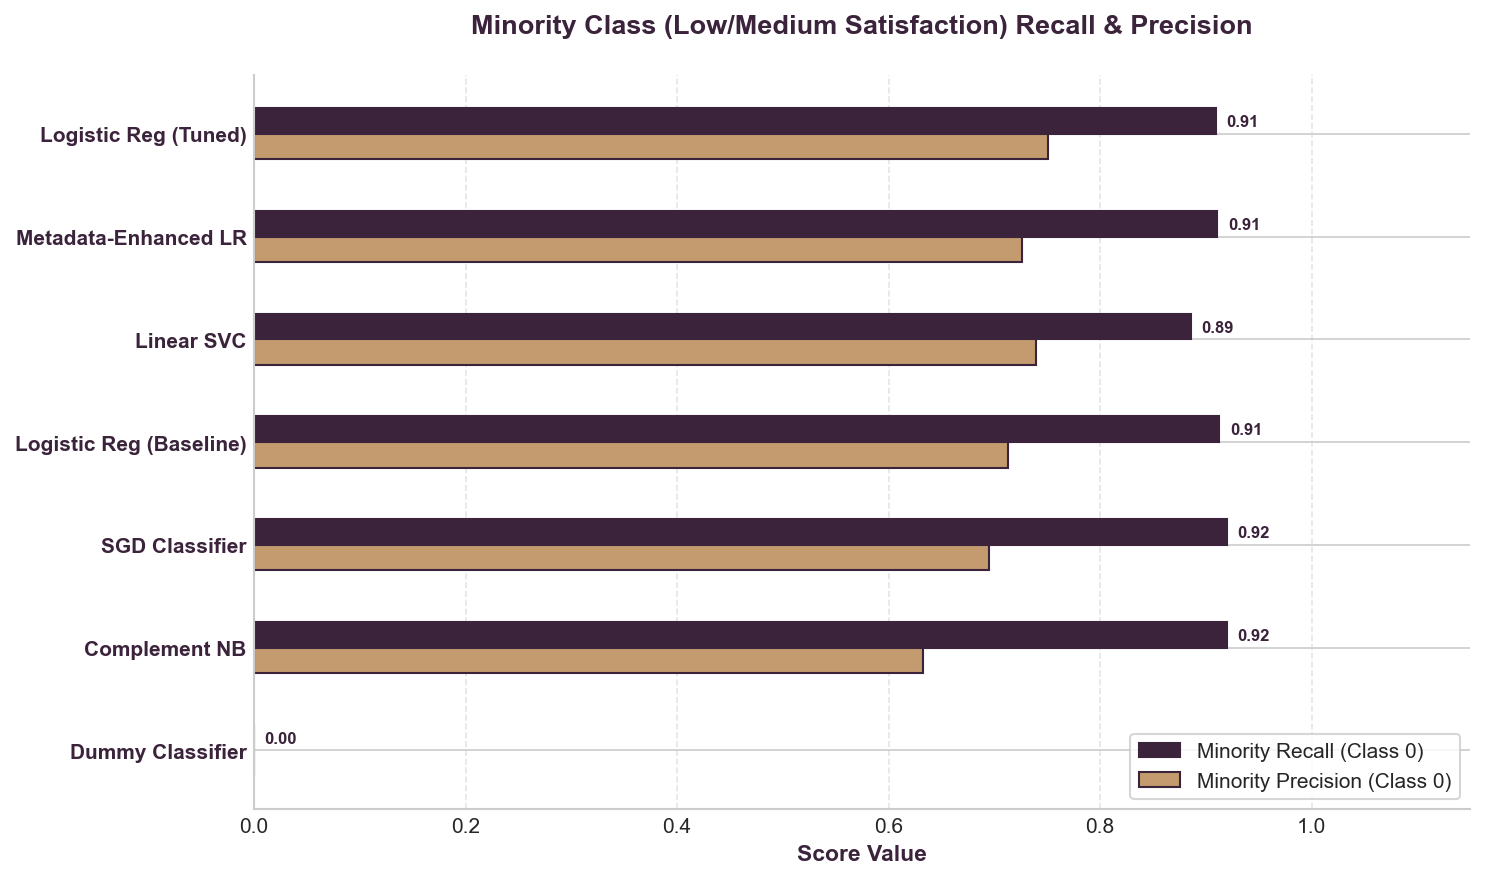


=== Best Model Confusion Matrix ===


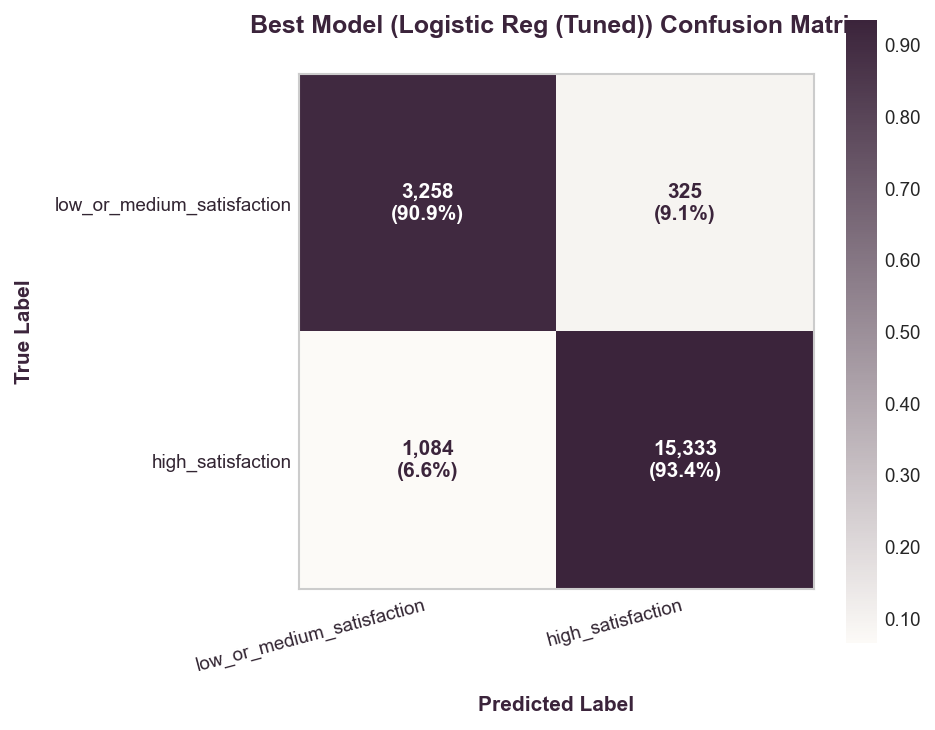

In [7]:
from IPython.display import Image, display

print("=== Performance Metrics Comparison ===")
display(Image(filename=str(figures_dir / "model_comparison_metrics.png")))

print("\n=== Class 0 Recall & Precision Comparison ===")
display(Image(filename=str(figures_dir / "model_comparison_minority_recall.png")))

print("\n=== Best Model Confusion Matrix ===")
display(Image(filename=str(figures_dir / "best_model_confusion_matrix.png")))


## 7. Best Model Selection & Rationale

According to our ranking strategy:
1. **Primary**: Macro F1-score
2. **Secondary**: Class 0 recall for low_or_medium_satisfaction
3. **Tertiary**: Weighted F1-score
4. **Quaternary**: Model simplicity

The **Tuned Logistic Regression** model achieved the highest Macro F1-score (**0.8891**) and a high recall for dissatisfied reviews (**90.93%**). It performs similarly to the Metadata-Enhanced model, but is significantly simpler and more deployment-friendly since it does not rely on collecting additional categorical inputs from customers.

### Limitations:
- **Feature Exclusions**: We strictly excluded data leakage columns (`rating`, `is_recommended`, `helpfulness`, feedback counts).
- **Semantics**: Bag-of-words / TF-IDF approaches ignore word ordering and contextual meaning.

---

## 🚀 Next Steps: Model Explainability
In the next branch **`feat/model-explainability`**, we will analyze:
- Local and global feature importances (e.g. using SHAP or LIME).
- Analysis of misclassified cases to identify beauty-specific domain vocabularies.
